# 2. Alpha Source Spectroscopy and Nuclide Identification

**Objective:** Analyze unknown alpha source spectrum, extract peak energies and probabilities, identify the nuclide, calculate energy resolutions, and discuss systematic errors.

## Setup and Helper Functions

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, optimize
import re

DATA_DIR = Path('.')

def load_alpha_spectrum_file(file_path):
    """Load alpha spectroscopy MCA data file.
    Returns: (channel_array, counts_array)
    """
    text = Path(file_path).read_text(encoding='utf-8', errors='ignore').splitlines()
    channels = []
    counts = []
    
    for line in text:
        match = re.match(r'\s*(\d+),\s*(\d+)', line)
        if match:
            channels.append(float(match.group(1)))
            counts.append(float(match.group(2)))
    
    return np.array(channels), np.array(counts)

def calcular_centroide(canais, contagens):
    """Calcula o centróide (média ponderada) de um pico."""
    canais = np.array(canais)
    contagens = np.array(contagens)
    
    if np.sum(contagens) == 0:
        return 0, 0, 0
        
    centroid = np.sum(canais * contagens) / np.sum(contagens)
    
    # Peak width (sigma)
    variance = np.sum(contagens * (canais - centroid)**2) / np.sum(contagens)
    peak_sigma = np.sqrt(variance)
    
    # Centroid uncertainty
    N_total = np.sum(contagens)
    sigma_centroid = peak_sigma / np.sqrt(N_total)
    
    return centroid, sigma_centroid, peak_sigma

def find_peaks_with_fwhm(channels, counts, threshold=100):
    """Find peaks in spectrum and calculate FWHM.
    Returns: (peak_channels, peak_heights, fwhm_values)
    """
    peaks, properties = signal.find_peaks(counts, height=threshold, distance=5)
    peak_heights = properties['peak_heights']
    
    # Calculate FWHM for each peak
    fwhm_values = []
    for peak_idx in peaks:
        peak_height = counts[peak_idx]
        half_max = peak_height / 2.0
        
        left_idx = peak_idx
        while left_idx > 0 and counts[left_idx] > half_max:
            left_idx -= 1
        
        right_idx = peak_idx
        while right_idx < len(counts) - 1 and counts[right_idx] > half_max:
            right_idx += 1
        
        fwhm = (right_idx - left_idx) * (channels[1] - channels[0]) if len(channels) > 1 else 0
        fwhm_values.append(fwhm)
    
    return channels[peaks], peak_heights, np.array(fwhm_values)

print('Setup complete. Helper functions loaded.')


Setup complete. Helper functions loaded.


## 2.1 Load Unknown Source Spectrum

AM-57 SOURCE SPECTRUM LOADED

File: AM57TRY1.ASC
Total channels: 1024
Channel range: 0 to 1023
Total counts: 38328

CALIBRATION PARAMETERS (from 01_energy_calibration)
Gain: 0.002207 MeV/channel
Intercept: 4.550794 MeV
E(C) = 0.002207 × C + 4.550794 MeV


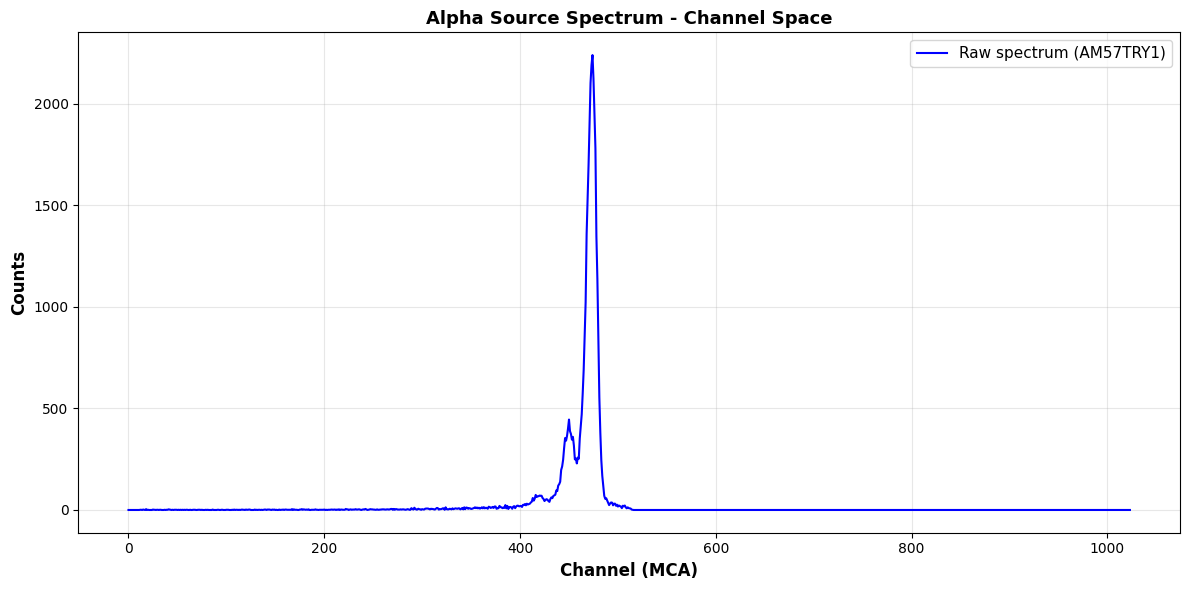

In [7]:
# ==========================================
# LOAD SOURCE SPECTRUM
# ==========================================
channels_raw, counts_raw = load_alpha_spectrum_file(DATA_DIR / 'AM57TRY1.ASC')

print("="*70)
print("AM-57 SOURCE SPECTRUM LOADED")
print("="*70)
print(f"\nFile: AM57TRY1.ASC")
print(f"Total channels: {len(channels_raw)}")
print(f"Channel range: {channels_raw.min():.0f} to {channels_raw.max():.0f}")
print(f"Total counts: {counts_raw.sum():.0f}")

# ==========================================
# CALIBRATION FROM NOTEBOOK 01
# ==========================================
# These values are from the energy calibration analysis (01_energy_calibration.ipynb)
m_p_weighted = 584.035959  # ch/dial
c_zero_weighted = -2061.602320  # ch
ganho_energia = 0.002207  # MeV/channel
b_energia = 4.550794  # MeV
sigma_ganho = 0.000001  # MeV/channel
sigma_c = 0.094427  # ch
sigma_b = 0.001064  # MeV

print("\n" + "="*70)
print("CALIBRATION PARAMETERS (from 01_energy_calibration)")
print("="*70)
print(f"Gain: {ganho_energia:.6f} MeV/channel")
print(f"Intercept: {b_energia:.6f} MeV")
print(f"E(C) = {ganho_energia:.6f} × C + {b_energia:.6f} MeV")

# ==========================================
# PLOT 1: ORIGINAL SPECTRUM (CHANNELS)
# ==========================================
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_raw, counts_raw, 'b-', linewidth=1.5, label='Raw spectrum (AM57TRY1)')
ax.set_xlabel('Channel (MCA)', fontsize=12, fontweight='bold')
ax.set_ylabel('Counts', fontsize=12, fontweight='bold')
ax.set_title('Alpha Source Spectrum - Channel Space', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 2.2 Peak Detection and Characterization

PEAK DETECTION AND ANALYSIS - MANUAL ROI

Manually defined ROIs:
  Peak 1: channels 400-425
  Peak 2: channels 430-460
  Peak 3: channels 460-490

----------------------------------------------------------------------
IDENTIFIED PEAKS (MANUAL ROI)
----------------------------------------------------------------------

Peak 1 (channels 400-425):
  Centroid:     415.26 ± 0.195 ch
  Energy:       5.4664 ± 0.0027 MeV
  Total counts: 1154
  Peak height:  74

Peak 2 (channels 430-460):
  Centroid:     448.86 ± 0.083 ch
  Energy:       5.5406 ± 0.0027 MeV
  Total counts: 6900
  Peak height:  445

Peak 3 (channels 460-490):
  Centroid:     472.75 ± 0.031 ch
  Energy:       5.5933 ± 0.0027 MeV
  Total counts: 28557
  Peak height:  2239


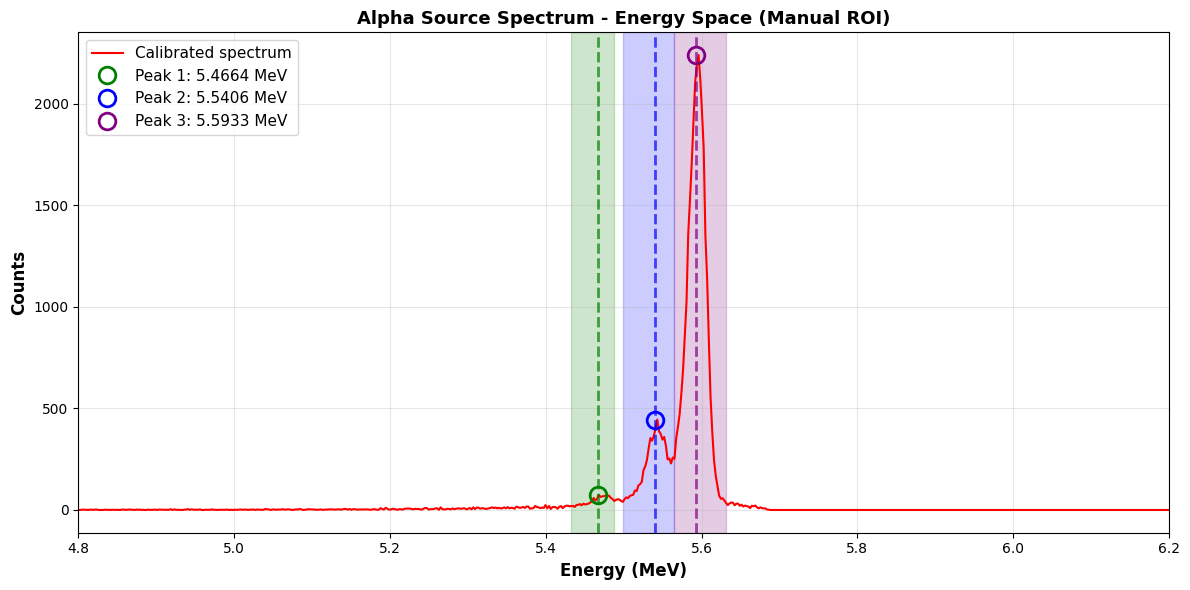

In [18]:
# ==========================================
# PEAK DETECTION - MANUAL ROI DEFINITION
# ==========================================
print("="*70)
print("PEAK DETECTION AND ANALYSIS - MANUAL ROI")
print("="*70)

# Manually define Regions of Interest (ROI)
roi_definitions = [
    {'name': 'Peak 1', 'ch_min': 400, 'ch_max': 425},
    {'name': 'Peak 2', 'ch_min': 430, 'ch_max': 460},
    {'name': 'Peak 3', 'ch_min': 460, 'ch_max': 490},
]

print(f"\nManually defined ROIs:")
for roi in roi_definitions:
    print(f"  {roi['name']}: channels {roi['ch_min']}-{roi['ch_max']}")

# Calculate centroids and uncertainties for each ROI
peak_data = []
for roi in roi_definitions:
    # Find indices within the ROI
    mask = (channels_raw >= roi['ch_min']) & (channels_raw <= roi['ch_max'])
    region_channels = channels_raw[mask]
    region_counts = counts_raw[mask]
    
    if len(region_channels) == 0 or np.sum(region_counts) == 0:
        print(f"\n⚠️  {roi['name']}: No counts in ROI!")
        continue
    
    # Calculate precise centroid
    centroid, sigma_centroid, peak_sigma = calcular_centroide(region_channels, region_counts)
    
    # Convert to energy
    energy = ganho_energia * (centroid - c_zero_weighted)
    sigma_energy = np.sqrt((sigma_ganho * (centroid - c_zero_weighted))**2 + 
                           (ganho_energia * sigma_centroid)**2 + 
                           sigma_b**2)
    
    total_counts = np.sum(region_counts)
    peak_height = np.max(region_counts)
    
    peak_data.append({
        'name': roi['name'],
        'ch_min': roi['ch_min'],
        'ch_max': roi['ch_max'],
        'channel': centroid,
        'sigma_ch': sigma_centroid,
        'energy': energy,
        'sigma_E': sigma_energy,
        'counts': total_counts,
        'height': peak_height
    })

# Sort by energy
peak_data.sort(key=lambda x: x['energy'])

print("\n" + "-"*70)
print("IDENTIFIED PEAKS (MANUAL ROI)")
print("-"*70)
for i, peak in enumerate(peak_data, 1):
    print(f"\n{peak['name']} (channels {peak['ch_min']}-{peak['ch_max']}):")
    print(f"  Centroid:     {peak['channel']:.2f} ± {peak['sigma_ch']:.3f} ch")
    print(f"  Energy:       {peak['energy']:.4f} ± {peak['sigma_E']:.4f} MeV")
    print(f"  Total counts: {peak['counts']:.0f}")
    print(f"  Peak height:  {peak['height']:.0f}")

# ==========================================
# PLOT 2: FINAL SPECTRUM (ENERGY) WITH MANUAL ROI
# ==========================================
energies = ganho_energia * (channels_raw - c_zero_weighted)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(energies, counts_raw, 'r-', linewidth=1.5, label='Calibrated spectrum')

# Mark detected peaks
colors = ['green', 'blue', 'purple']
for i, peak in enumerate(peak_data):
    color = colors[i % len(colors)]
    ax.plot(peak['energy'], peak['height'], 'o', color=color, markersize=12, 
            markeredgewidth=2, markerfacecolor='none', label=f"{peak['name']}: {peak['energy']:.4f} MeV")
    
    # Mark the ROI boundaries in energy space
    ch_min_energy = ganho_energia * (peak['ch_min'] - c_zero_weighted)
    ch_max_energy = ganho_energia * (peak['ch_max'] - c_zero_weighted)
    ax.axvspan(ch_min_energy, ch_max_energy, alpha=0.2, color=color)
    
    ax.axvline(peak['energy'], color=color, linestyle='--', linewidth=2, alpha=0.7)

ax.set_xlabel('Energy (MeV)', fontsize=12, fontweight='bold')
ax.set_ylabel('Counts', fontsize=12, fontweight='bold')
ax.set_title('Alpha Source Spectrum - Energy Space (Manual ROI)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(4.8, 6.2)
plt.tight_layout()
plt.show()


## 2.2a Visualize Peak Regions Selected for Centroid Analysis

VISUALIZING MANUALLY DEFINED ROI

Peak 1:
  ROI range:           400-425 ch
  Calculated centroid: 415.26 ch
  Centroid uncertainty: 0.195 ch
  Energy:              5.4664 MeV
  Energy uncertainty:  0.0027 MeV

Peak 2:
  ROI range:           430-460 ch
  Calculated centroid: 448.86 ch
  Centroid uncertainty: 0.083 ch
  Energy:              5.5406 MeV
  Energy uncertainty:  0.0027 MeV

Peak 3:
  ROI range:           460-490 ch
  Calculated centroid: 472.75 ch
  Centroid uncertainty: 0.031 ch
  Energy:              5.5933 MeV
  Energy uncertainty:  0.0027 MeV


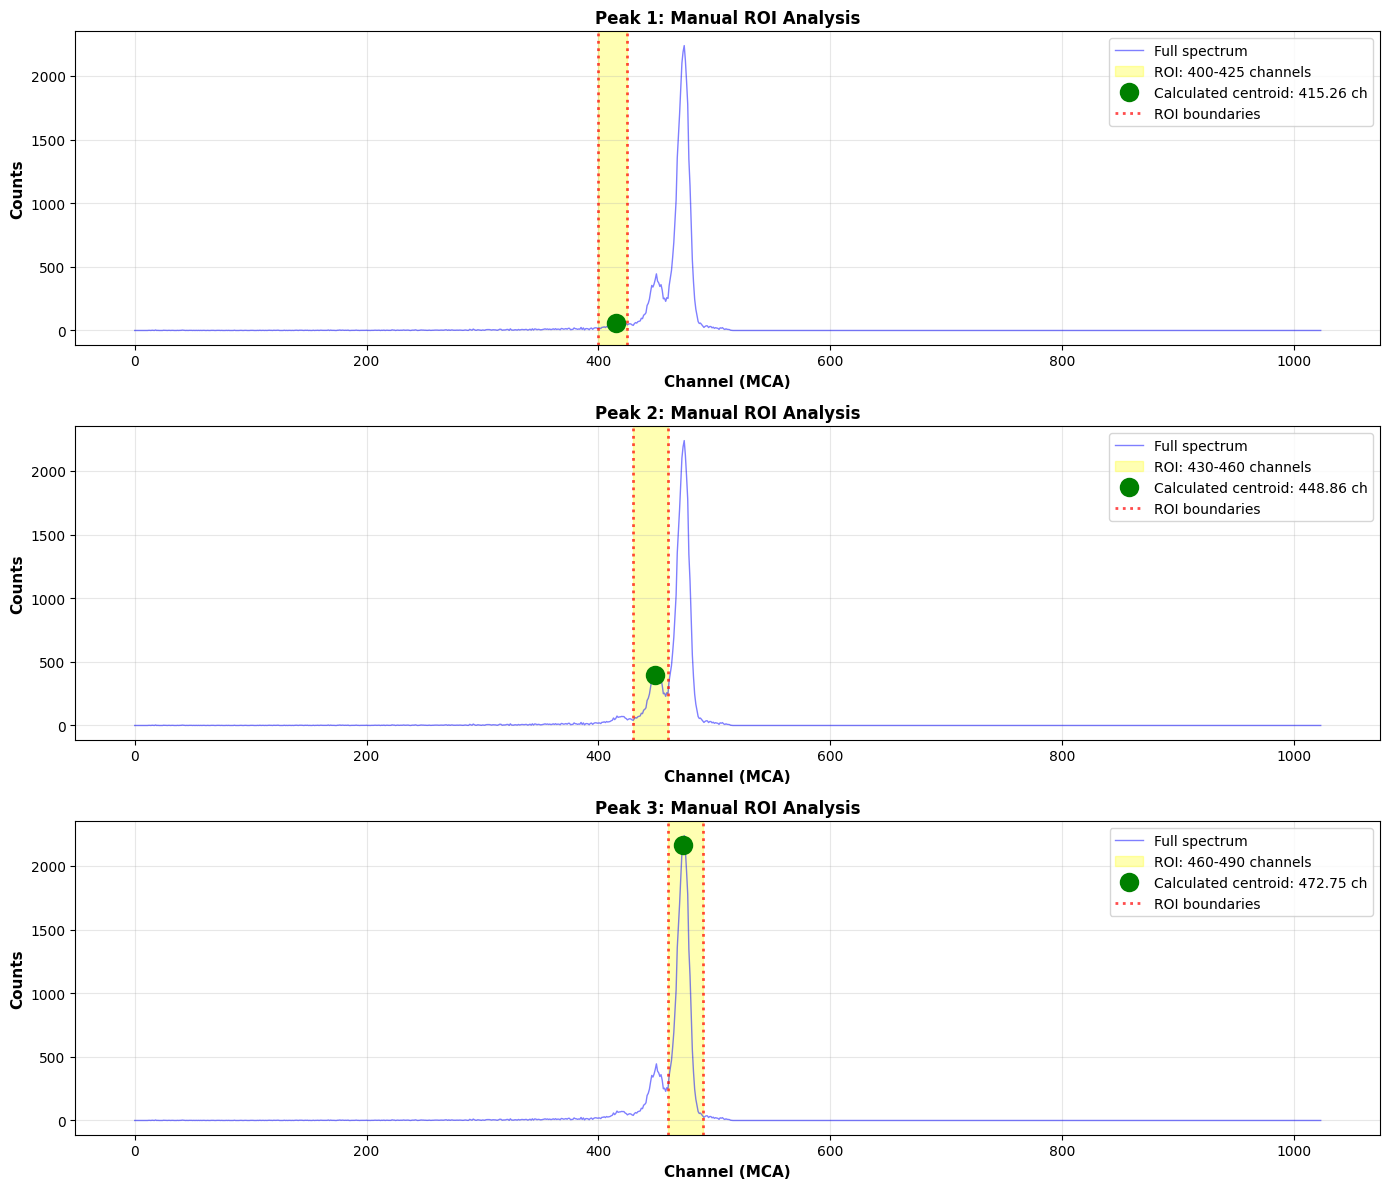

In [19]:
# ==========================================
# VISUALIZE PEAK REGIONS FOR CENTROID SELECTION
# ==========================================
print("="*70)
print("VISUALIZING MANUALLY DEFINED ROI")
print("="*70)

fig, axes = plt.subplots(len(peak_data), 1, figsize=(14, 4*len(peak_data)))
if len(peak_data) == 1:
    axes = [axes]

for idx, (ax, peak) in enumerate(zip(axes, peak_data)):
    # Plot full spectrum
    ax.plot(channels_raw, counts_raw, 'b-', linewidth=1, alpha=0.5, label='Full spectrum')
    
    # Highlight the ROI
    ax.axvspan(peak['ch_min'], peak['ch_max'], 
               alpha=0.3, color='yellow', label=f"ROI: {peak['ch_min']}-{peak['ch_max']} channels")
    
    # Mark the calculated centroid
    centroid_count = np.interp(peak['channel'], channels_raw, counts_raw)
    ax.plot(peak['channel'], centroid_count, 'go', markersize=12, markeredgewidth=2,
            label=f'Calculated centroid: {peak["channel"]:.2f} ch')
    
    # Mark the ROI boundaries
    ax.axvline(peak['ch_min'], color='red', linestyle=':', linewidth=2, alpha=0.7, label='ROI boundaries')
    ax.axvline(peak['ch_max'], color='red', linestyle=':', linewidth=2, alpha=0.7)
    
    ax.set_xlabel('Channel (MCA)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Counts', fontsize=11, fontweight='bold')
    ax.set_title(f"{peak['name']}: Manual ROI Analysis", 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='upper right')
    
    print(f"\n{peak['name']}:")
    print(f"  ROI range:           {peak['ch_min']}-{peak['ch_max']} ch")
    print(f"  Calculated centroid: {peak['channel']:.2f} ch")
    print(f"  Centroid uncertainty: {peak['sigma_ch']:.3f} ch")
    print(f"  Energy:              {peak['energy']:.4f} MeV")
    print(f"  Energy uncertainty:  {peak['sigma_E']:.4f} MeV")

plt.tight_layout()
plt.show()



FULL SPECTRUM - MANUAL ROI ANALYSIS


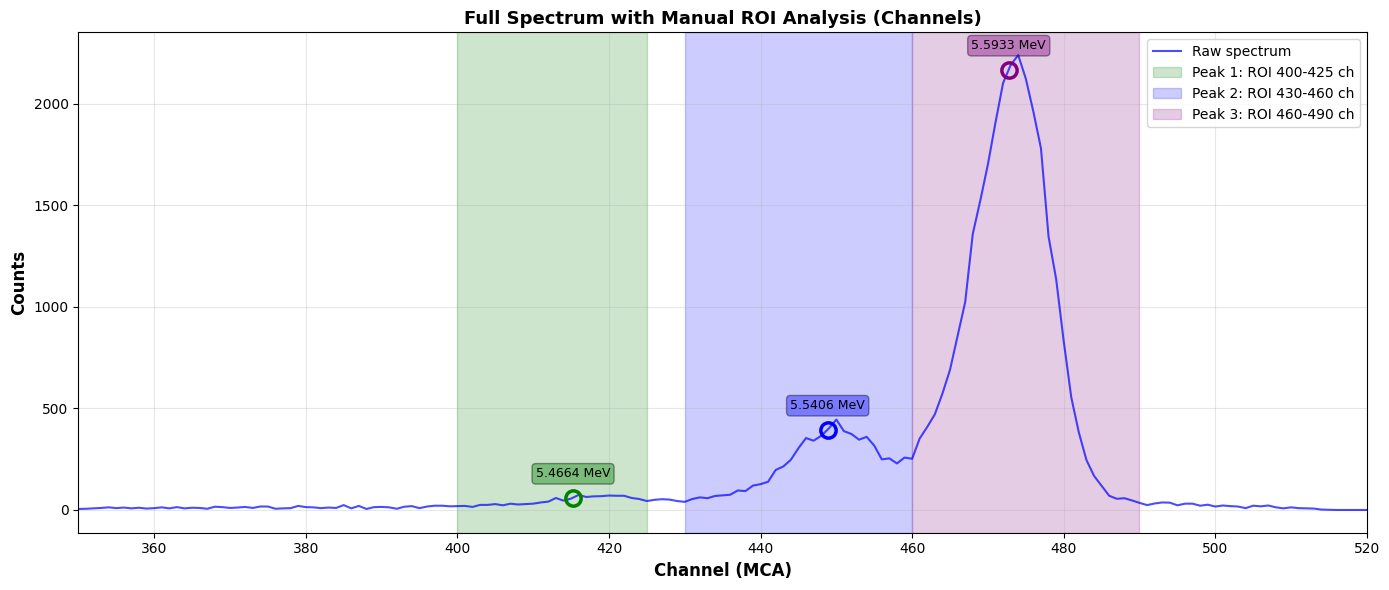


Manual ROI Summary:
  Peak 1: ch 400-425 → centroid 415.26 ch → 5.4664 MeV (1154 cts)
  Peak 2: ch 430-460 → centroid 448.86 ch → 5.5406 MeV (6900 cts)
  Peak 3: ch 460-490 → centroid 472.75 ch → 5.5933 MeV (28557 cts)


In [23]:
# ==========================================
# FULL SPECTRUM WITH MANUAL ROI OVERLAYS
# ==========================================
print("\n" + "="*70)
print("FULL SPECTRUM - MANUAL ROI ANALYSIS")
print("="*70)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(channels_raw, counts_raw, 'b-', linewidth=1.5, label='Raw spectrum', alpha=0.7)

# Overlay manual ROI definitions
colors = ['green', 'blue', 'purple']
for i, (peak, color) in enumerate(zip(peak_data, colors)):
    # Highlight ROI region
    ax.axvspan(peak['ch_min'], peak['ch_max'], 
               alpha=0.2, color=color, label=f"{peak['name']}: ROI {peak['ch_min']}-{peak['ch_max']} ch")
    
    # Mark centroid
    centroid_count = np.interp(peak['channel'], channels_raw, counts_raw)
    ax.plot(peak['channel'], centroid_count, 'o', color=color, markersize=11, 
            markeredgewidth=2.5, markerfacecolor='none', markeredgecolor=color)
    
    # Add energy label at peak
    ax.text(peak['channel'], centroid_count + 100, f"{peak['energy']:.4f} MeV", 
            ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor=color, alpha=0.4))

ax.set_xlabel('Channel (MCA)', fontsize=12, fontweight='bold')
ax.set_ylabel('Counts', fontsize=12, fontweight='bold')
ax.set_title('Full Spectrum with Manual ROI Analysis (Channels)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(350, 520)  # Focus on peak region
plt.tight_layout()
plt.show()

print("\nManual ROI Summary:")
for peak in peak_data:
    print(f"  {peak['name']:6s}: ch {peak['ch_min']}-{peak['ch_max']:3d} → centroid {peak['channel']:.2f} ch → {peak['energy']:.4f} MeV ({peak['counts']:.0f} cts)")


## 2.3 Energy Resolution Calculation

In [21]:
# ==========================================
# ENERGY RESOLUTION
# ==========================================
print("\n" + "="*70)
print("ENERGY RESOLUTION ANALYSIS")
print("="*70)

# Calculate FWHM for each peak using the ROI data
for i, peak in enumerate(peak_data, 1):
    # Extract spectrum within ROI
    mask = (channels_raw >= peak['ch_min']) & (channels_raw <= peak['ch_max'])
    roi_counts = counts_raw[mask]
    
    if len(roi_counts) > 0:
        # Find FWHM by looking at half-max points
        peak_max = np.max(roi_counts)
        half_max = peak_max / 2.0
        above_half = roi_counts >= half_max
        if np.any(above_half):
            fwhm_indices = np.where(above_half)[0]
            fwhm_ch = fwhm_indices[-1] - fwhm_indices[0]
        else:
            fwhm_ch = peak['ch_max'] - peak['ch_min']
        
        fwhm_energy = ganho_energia * fwhm_ch
        if peak['energy'] > 0:
            relative_resolution = (fwhm_energy / peak['energy']) * 100
        else:
            relative_resolution = 0
        
        print(f"\n{peak['name']} (E = {peak['energy']:.4f} MeV):")
        print(f"  FWHM (channels): {fwhm_ch:.1f}")
        print(f"  FWHM (energy):   {fwhm_energy:.4f} MeV")
        print(f"  Resolution:      {relative_resolution:.2f}%")

# ==========================================
# NUCLIDE IDENTIFICATION
# ==========================================
print("\n" + "="*70)
print("NUCLIDE IDENTIFICATION")
print("="*70)

# Common alpha emitters with energies around 5.4-5.6 MeV
alpha_emitters = {
    'Am-241':  [5.486, 5.442],       # (84.8%, 13%)
    'Am-243':  [5.438, 5.380],       # (12.8%, 0.36%)
    'Cm-243':  [5.741, 5.714],       # (11.6%, 1%)
    'Cm-244':  [5.805, 5.763],       # (76.9%, 0.76%)
    'Po-210':  [5.304],               # (100%)
    'Po-209':  [4.883],               # (100%)
}

print("\nKnown Alpha Emitter Lines (common isotopes):")
for isotope, lines in alpha_emitters.items():
    lines_str = ', '.join([f'{E:.3f} MeV' for E in lines])
    print(f"  {isotope:8s}: {lines_str}")

print("\n" + "-"*70)
print("MEASURED vs EXPECTED ENERGIES")
print("-"*70)

# Analyze peaks
for i, peak in enumerate(peak_data):
    print(f"\n{peak['name']}: {peak['energy']:.4f} ± {peak['sigma_E']:.4f} MeV")
    
    # Find closest Am-241 line
    closest_am241 = min(alpha_emitters['Am-241'], key=lambda x: abs(x - peak['energy']))
    energy_diff = peak['energy'] - closest_am241
    rel_error = (energy_diff / closest_am241) * 100
    
    print(f"  Closest Am-241 line: {closest_am241:.3f} MeV")
    print(f"  Energy difference: {energy_diff:+.4f} MeV ({rel_error:+.2f}%)")
    
    if abs(energy_diff) < 0.030:
        print(f"  ✓ MATCH within tolerance")
    else:
        print(f"  ✗ Deviation exceeds 30 keV")

print("\n" + "="*70)
print("SUMMARY - MANUAL ROI ANALYSIS")
print("="*70)
print(f"\nPeaks identified: {len(peak_data)}")
for peak in peak_data:
    print(f"  {peak['name']:6s}: {peak['energy']:.4f} MeV ({peak['counts']:.0f} counts)")

print(f"\nEnergy range: {peak_data[0]['energy']:.4f} - {peak_data[-1]['energy']:.4f} MeV")
print(f"Total counts in ROI: {sum(p['counts'] for p in peak_data):.0f}")
print(f"\nCalibration: E(C) = {ganho_energia:.6f} × C + {b_energia:.6f} MeV")
print(f"File analyzed: AM57TRY1.ASC")



ENERGY RESOLUTION ANALYSIS

Peak 1 (E = 5.4664 MeV):
  FWHM (channels): 14.0
  FWHM (energy):   0.0309 MeV
  Resolution:      0.57%

Peak 2 (E = 5.5406 MeV):
  FWHM (channels): 16.0
  FWHM (energy):   0.0353 MeV
  Resolution:      0.64%

Peak 3 (E = 5.5933 MeV):
  FWHM (channels): 11.0
  FWHM (energy):   0.0243 MeV
  Resolution:      0.43%

NUCLIDE IDENTIFICATION

Known Alpha Emitter Lines (common isotopes):
  Am-241  : 5.486 MeV, 5.442 MeV
  Am-243  : 5.438 MeV, 5.380 MeV
  Cm-243  : 5.741 MeV, 5.714 MeV
  Cm-244  : 5.805 MeV, 5.763 MeV
  Po-210  : 5.304 MeV
  Po-209  : 4.883 MeV

----------------------------------------------------------------------
MEASURED vs EXPECTED ENERGIES
----------------------------------------------------------------------

Peak 1: 5.4664 ± 0.0027 MeV
  Closest Am-241 line: 5.486 MeV
  Energy difference: -0.0196 MeV (-0.36%)
  ✓ MATCH within tolerance

Peak 2: 5.5406 ± 0.0027 MeV
  Closest Am-241 line: 5.486 MeV
  Energy difference: +0.0546 MeV (+1.00%)
  ✗